In [1]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models,get_features
from dinosaw.utils import do_2D_pca

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False
torch.cuda.empty_cache()

flash attention installed


In [2]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'dvt','alibi_dv2_coco', 'alibi_dv2_coco_e1',)
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

In [3]:
SF = 1

img_fname = "micro/NMC.png"\
# img_fname = "tests/black_square_518.png"
# img_fname = "tests/diff_shapes_518.png"
# img_fname = "tests/default_image.jpg"
# img_fname = "dalmatian-facts.jpg"
# img_fname = "micro/needle_block_.png"
# img_fname = "tests/z_c_w.png"
# img_fname = "micro/000394.jpg"
_img = Image.open(f"../../images/{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.BILINEAR)

In [4]:
features = {}
features_reduced = {}

In [5]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, False, False, device=DEVICE)
    features[model_key] = feats

In [6]:
for model_key in enabled_models:
    feats = features[model_key]
    features_reduced[model_key] = do_2D_pca(feats, 9, pre_norm='std', post_norm='minmax')[:, :, 0:3]

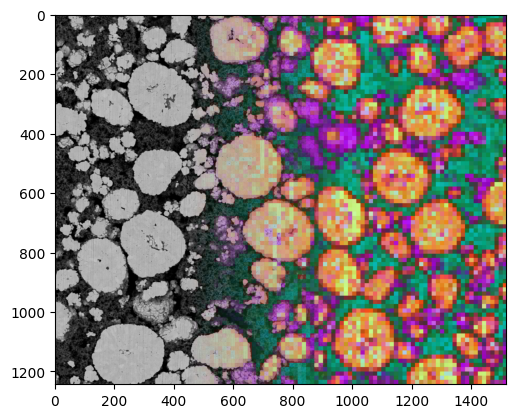

In [25]:
from skimage.transform import resize
img_arr = np.array(_img)
feats = features_reduced['alibi_dv2_coco_e1']

feats_hr = (255 * resize(feats, img_arr.shape, order=0)).astype(np.uint8)

out_arr = np.zeros_like(img_arr)
h, w, _ = img_arr.shape

# Define midpoint region width (in pixels) for blending
blend_width = int(0.33 * w)  # 10% of width
mid = 200 + w // 3

for y in range(h):
    for x in range(w):
        if x < mid - blend_width // 2:
            out_arr[y, x, :] = img_arr[y, x, :]
        elif x > mid + blend_width // 2:
            out_arr[y, x, :] = feats_hr[y, x, :]
        else:
            # Linear interpolation in blend region
            alpha = (x - (mid - blend_width // 2)) / blend_width
            out_arr[y, x, :] = (1 - alpha) * img_arr[y, x, :] + alpha * feats_hr[y, x, :]

out_arr = out_arr.astype(np.uint8)
plt.imshow(out_arr)


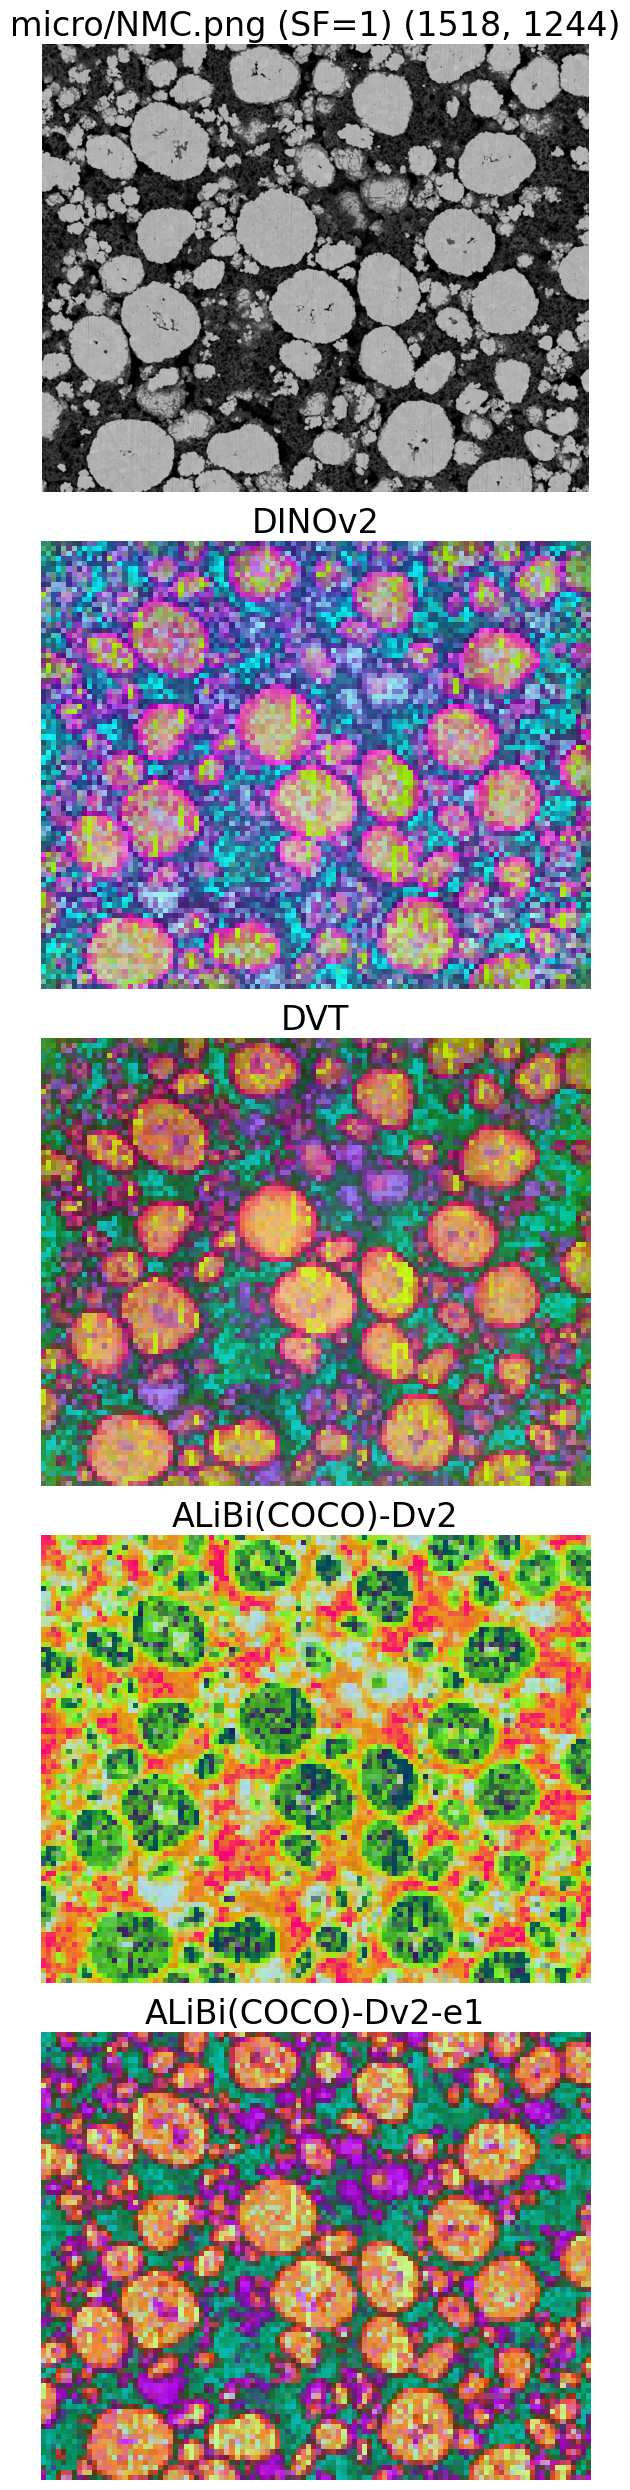

In [7]:
# %%capture
fig, axs = plt.subplots(nrows=1 + len(enabled_models), ncols=1, figsize=(25, 25))


axs[0].imshow(_img)
axs[0].set_axis_off()
axs[0].set_title(f"{img_fname} (SF={SF}) {_img.size}", fontsize=24)
for i, model_key in enumerate(enabled_models):
    feats_red = features_reduced[model_key]
    ax = axs[i + 1]
    ax.set_title(model_names[model_key], fontsize=24)
    ax.imshow(feats_red)
    ax.set_axis_off()
plt.tight_layout()